# Exploratory Data Analysis (EDA)

This notebook analyzes the crop disease datasets used in the project:

- PlantDoc
- Web-sourced dataset
- Combined dataset

It generates:
- dataset summaries
- class distribution tables
- bar charts
- sample image visualizations


In [1]:
from pathlib import Path
from collections import defaultdict
import random

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE_DIR = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

PLANTDOC_TRAIN = BASE_DIR / 'data' / 'plantdoc' / 'train'
PLANTDOC_TEST = BASE_DIR / 'data' / 'plantdoc' / 'test'
WEB_ROOT = BASE_DIR / 'data' / 'web_sourced' / 'Plant Leaf Disease Detection Using Deep Learning - A Multi-Dataset Approach (Web sourced Dataset)'
WEB_TRAIN = WEB_ROOT / 'train'
WEB_TEST = WEB_ROOT / 'test'
COMBINED_DIR = BASE_DIR / 'data' / 'combined_dataset'
TRAIN_DIR = BASE_DIR / 'data' / 'train'
VAL_DIR = BASE_DIR / 'data' / 'val'
TEST_DIR = BASE_DIR / 'data' / 'test'

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
SEED = 42
random.seed(SEED)

print('Base directory:', BASE_DIR)
print('PlantDoc train exists:', PLANTDOC_TRAIN.exists())
print('Web train exists:', WEB_TRAIN.exists())
print('Combined exists:', COMBINED_DIR.exists())


Base directory: C:\Users\Ubaid\Desktop\CDD
PlantDoc train exists: True
Web train exists: True
Combined exists: True


## Helper functions

In [2]:
def count_images_in_class_dir(class_dir: Path):
    return len([f for f in class_dir.iterdir() if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS])

def dataset_counts(root_dir: Path):
    if not root_dir.exists():
        return pd.DataFrame(columns=['class_name', 'count'])

    rows = []
    for class_dir in sorted([d for d in root_dir.iterdir() if d.is_dir()]):
        rows.append({
            'class_name': class_dir.name,
            'count': count_images_in_class_dir(class_dir)
        })
    return pd.DataFrame(rows)

def split_dataset_counts(split_dirs):
    summary = defaultdict(lambda: {'train': 0, 'val': 0, 'test': 0, 'total': 0})
    for split_name, split_dir in split_dirs.items():
        if not split_dir.exists():
            continue
        for class_dir in [d for d in split_dir.iterdir() if d.is_dir()]:
            count = count_images_in_class_dir(class_dir)
            summary[class_dir.name][split_name] = count
            summary[class_dir.name]['total'] += count

    rows = []
    for cls, counts in sorted(summary.items()):
        rows.append({
            'class_name': cls,
            'train': counts['train'],
            'val': counts['val'],
            'test': counts['test'],
            'total': counts['total']
        })
    return pd.DataFrame(rows)

def show_bar_chart(df, x_col='class_name', y_col='count', title='Class Distribution', figsize=(14,6), rotation=90):
    if df.empty:
        print('No data available for plotting.')
        return
    plt.figure(figsize=figsize)
    plt.bar(df[x_col], df[y_col])
    plt.xticks(rotation=rotation)
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def sample_images(root_dir: Path, samples_per_class=2, max_classes=6):
    if not root_dir.exists():
        print(f'Missing directory: {root_dir}')
        return

    class_dirs = sorted([d for d in root_dir.iterdir() if d.is_dir()])[:max_classes]
    selected = []
    for class_dir in class_dirs:
        images = [f for f in class_dir.iterdir() if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS]
        if not images:
            continue
        chosen = random.sample(images, min(samples_per_class, len(images)))
        for img_path in chosen:
            selected.append((class_dir.name, img_path))

    if not selected:
        print('No images found.')
        return

    cols = samples_per_class
    rows = len(selected) // cols + int(len(selected) % cols != 0)
    plt.figure(figsize=(4*cols, 3*rows))

    for idx, (label, img_path) in enumerate(selected, start=1):
        try:
            img = Image.open(img_path).convert('RGB')
            plt.subplot(rows, cols, idx)
            plt.imshow(img)
            plt.title(label)
            plt.axis('off')
        except Exception as e:
            print(f'Could not open {img_path}: {e}')

    plt.tight_layout()
    plt.show()


## 1. PlantDoc dataset summary

In [3]:
plantdoc_train_df = dataset_counts(PLANTDOC_TRAIN)
plantdoc_test_df = dataset_counts(PLANTDOC_TEST)

plantdoc_summary = plantdoc_train_df.merge(
    plantdoc_test_df,
    on='class_name',
    how='outer',
    suffixes=('_train', '_test')
).fillna(0)

plantdoc_summary['count_train'] = plantdoc_summary['count_train'].astype(int)
plantdoc_summary['count_test'] = plantdoc_summary['count_test'].astype(int)
plantdoc_summary['total'] = plantdoc_summary['count_train'] + plantdoc_summary['count_test']
plantdoc_summary = plantdoc_summary.sort_values('total', ascending=False)

plantdoc_summary

,class_name,count_train,count_test,total
23,Tomato_leaf_yellow_virus,223,15,238
12,Potato_leaf_late_blight,200,8,208
8,Corn_leaf_blight,182,12,194
11,Potato_leaf_early_blight,157,14,171
18,Tomato_Septoria_leaf_spot,145,12,157
15,Squash_Powdery_mildew_leaf,124,6,130
13,Raspberry_leaf,112,7,119
9,Corn_rust_leaf,107,10,117
5,Blueberry_leaf,106,11,117
10,Peach_leaf,103,9,112


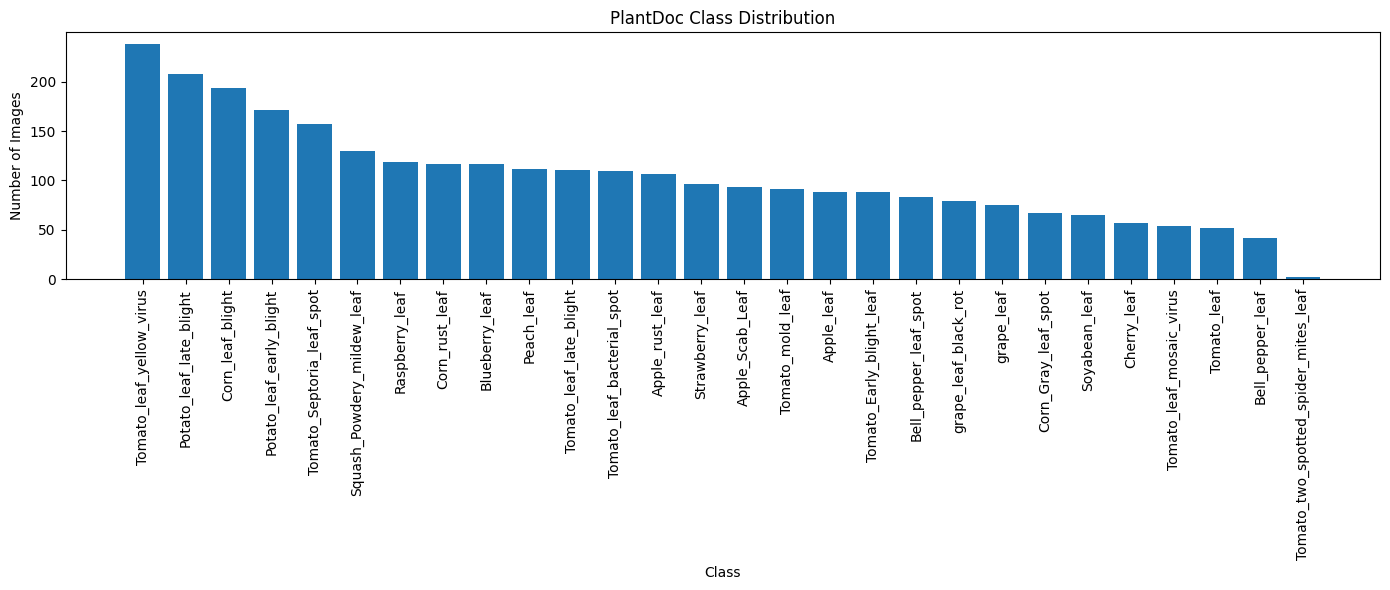

In [4]:
show_bar_chart(
    plantdoc_summary[['class_name', 'total']],
    y_col='total',
    title='PlantDoc Class Distribution'
)

## 2. Web-sourced dataset summary

In [5]:
web_train_df = dataset_counts(WEB_TRAIN)
web_test_df = dataset_counts(WEB_TEST)

web_summary = web_train_df.merge(
    web_test_df,
    on='class_name',
    how='outer',
    suffixes=('_train', '_test')
).fillna(0)

web_summary['count_train'] = web_summary['count_train'].astype(int)
web_summary['count_test'] = web_summary['count_test'].astype(int)
web_summary['total'] = web_summary['count_train'] + web_summary['count_test']
web_summary = web_summary.sort_values('total', ascending=False)

web_summary

,class_name,count_train,count_test,total
1,apple leaf rust,118,22,140
2,apple leaf scab,107,22,129
6,corn leaf rust,80,11,91
10,tomato leaf early blight,80,11,91
5,corn leaf blight,78,11,89
15,tomato septoria leaf spot,75,11,86
3,corn gray leaf spot,68,11,79
12,tomato leaf late blight,66,11,77
13,tomato leaf mold,64,11,75
9,tomato leaf bacterial spot,62,11,73


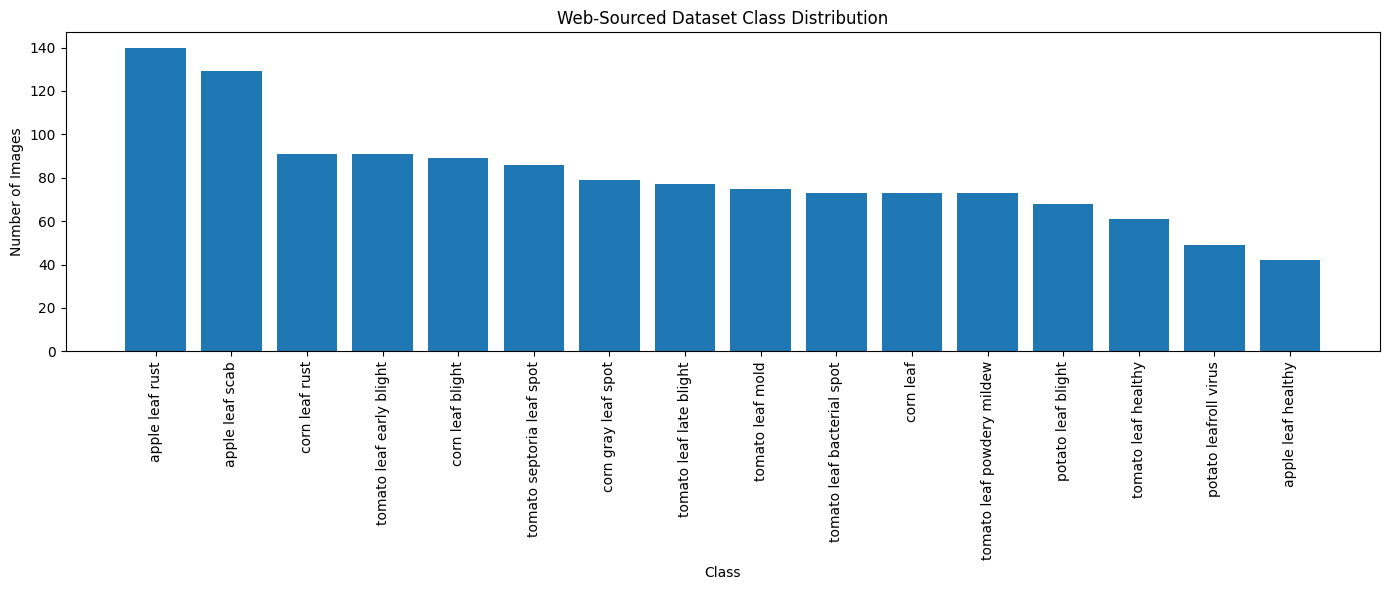

In [14]:
show_bar_chart(
    web_summary[['class_name', 'total']],
    y_col='total',
    title='Web-Sourced Dataset Class Distribution'
)

## 3. Combined dataset summary

In [12]:
combined_df = dataset_counts(COMBINED_DIR).sort_values('count', ascending=False)
combined_df

,class_name,count
4,corn_leaf_blight,283
7,potato_leaf_blight,276
1,apple_leaf_rust,246
15,tomato_septoria_leaf_spot,243
2,apple_leaf_scab,222
6,corn_leaf_rust,208
12,tomato_leaf_late_blight,188
9,tomato_leaf_bacterial_spot,183
10,tomato_leaf_early_blight,179
13,tomato_leaf_mould,166


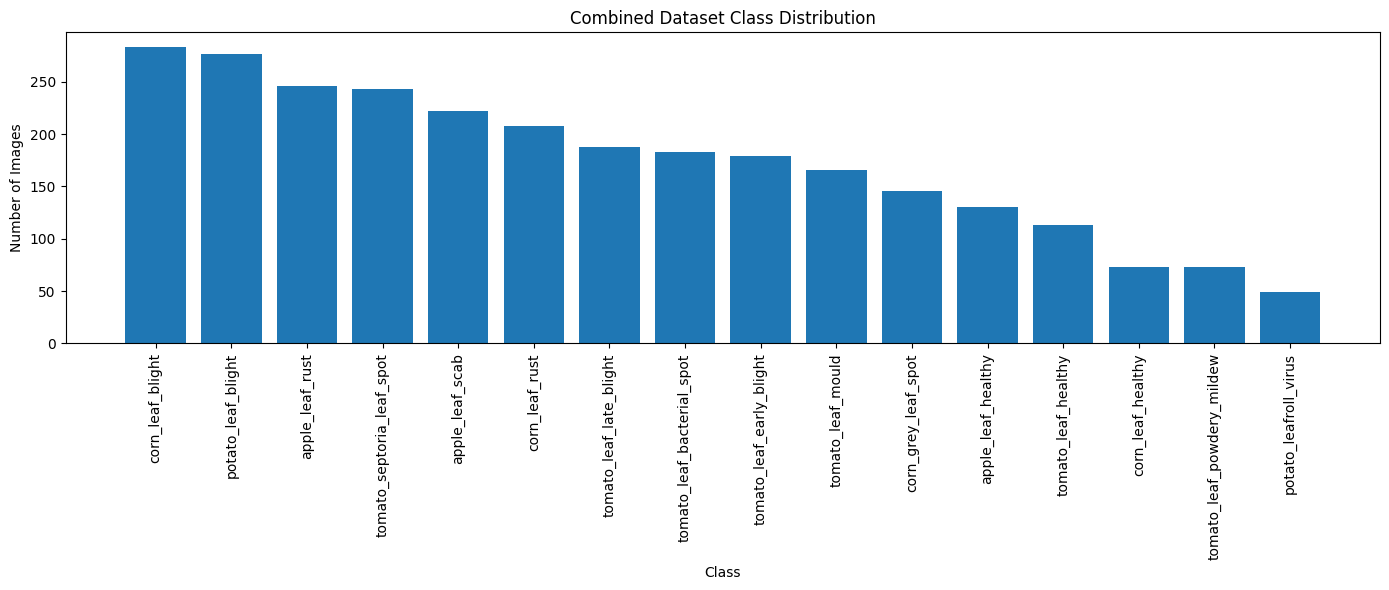

In [13]:
show_bar_chart(
    combined_df,
    y_col='count',
    title='Combined Dataset Class Distribution'
)

## 4. Final train/val/test split summary

In [8]:
split_summary = split_dataset_counts({
    'train': TRAIN_DIR,
    'val': VAL_DIR,
    'test': TEST_DIR,
})

split_summary = split_summary.sort_values('total', ascending=False)
split_summary

,class_name,train,val,test,total
4,corn_leaf_blight,198,42,43,283
7,potato_leaf_blight,193,41,42,276
1,apple_leaf_rust,172,36,38,246
15,tomato_septoria_leaf_spot,170,36,37,243
2,apple_leaf_scab,155,33,34,222
6,corn_leaf_rust,145,31,32,208
12,tomato_leaf_late_blight,131,28,29,188
9,tomato_leaf_bacterial_spot,128,27,28,183
10,tomato_leaf_early_blight,125,26,28,179
13,tomato_leaf_mould,116,24,26,166


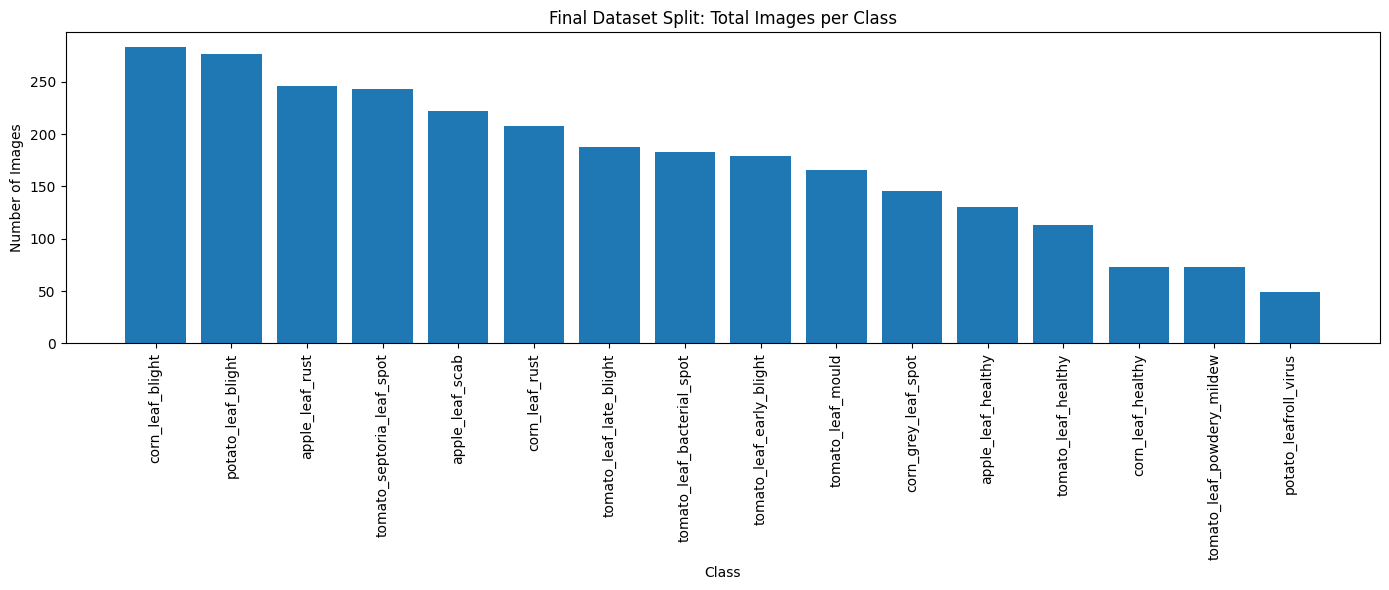

In [9]:
show_bar_chart(
    split_summary[['class_name', 'total']],
    y_col='total',
    title='Final Dataset Split: Total Images per Class'
)

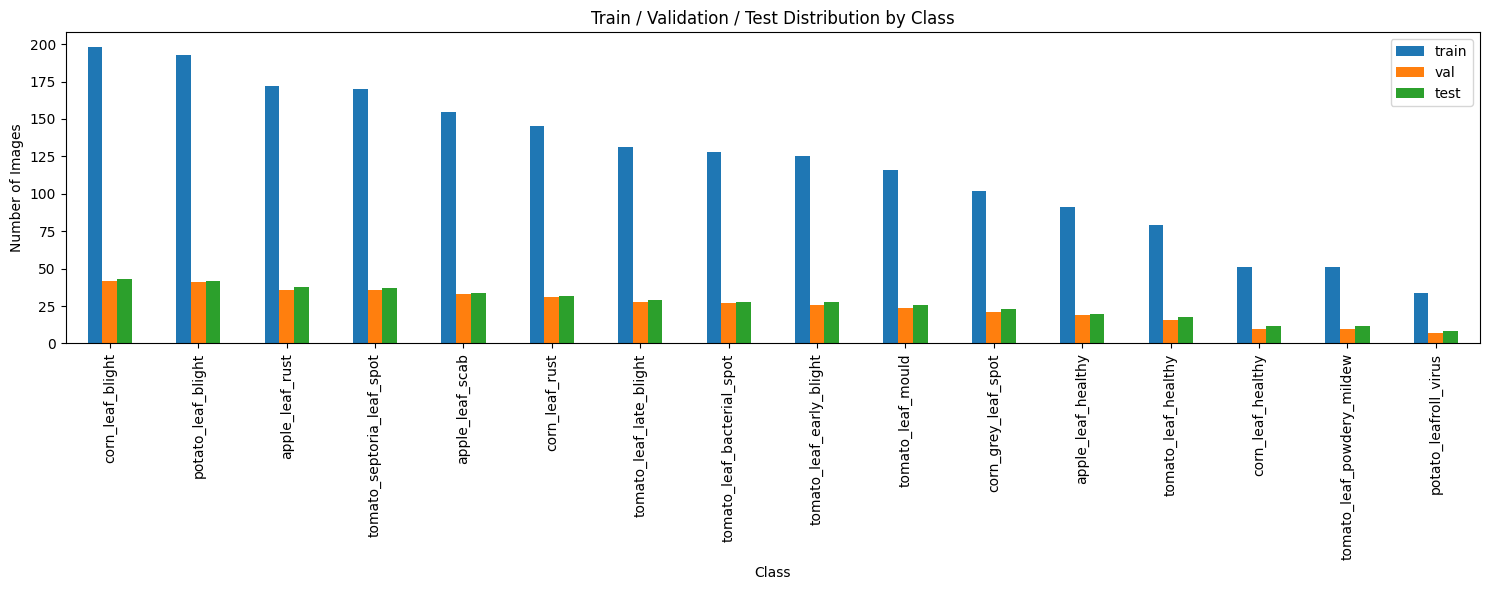

In [10]:
if not split_summary.empty:
    split_summary.plot(x='class_name', y=['train', 'val', 'test'], kind='bar', figsize=(15, 6))
    plt.title('Train / Validation / Test Distribution by Class')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print('Split summary is empty.')


## 5. Sample images

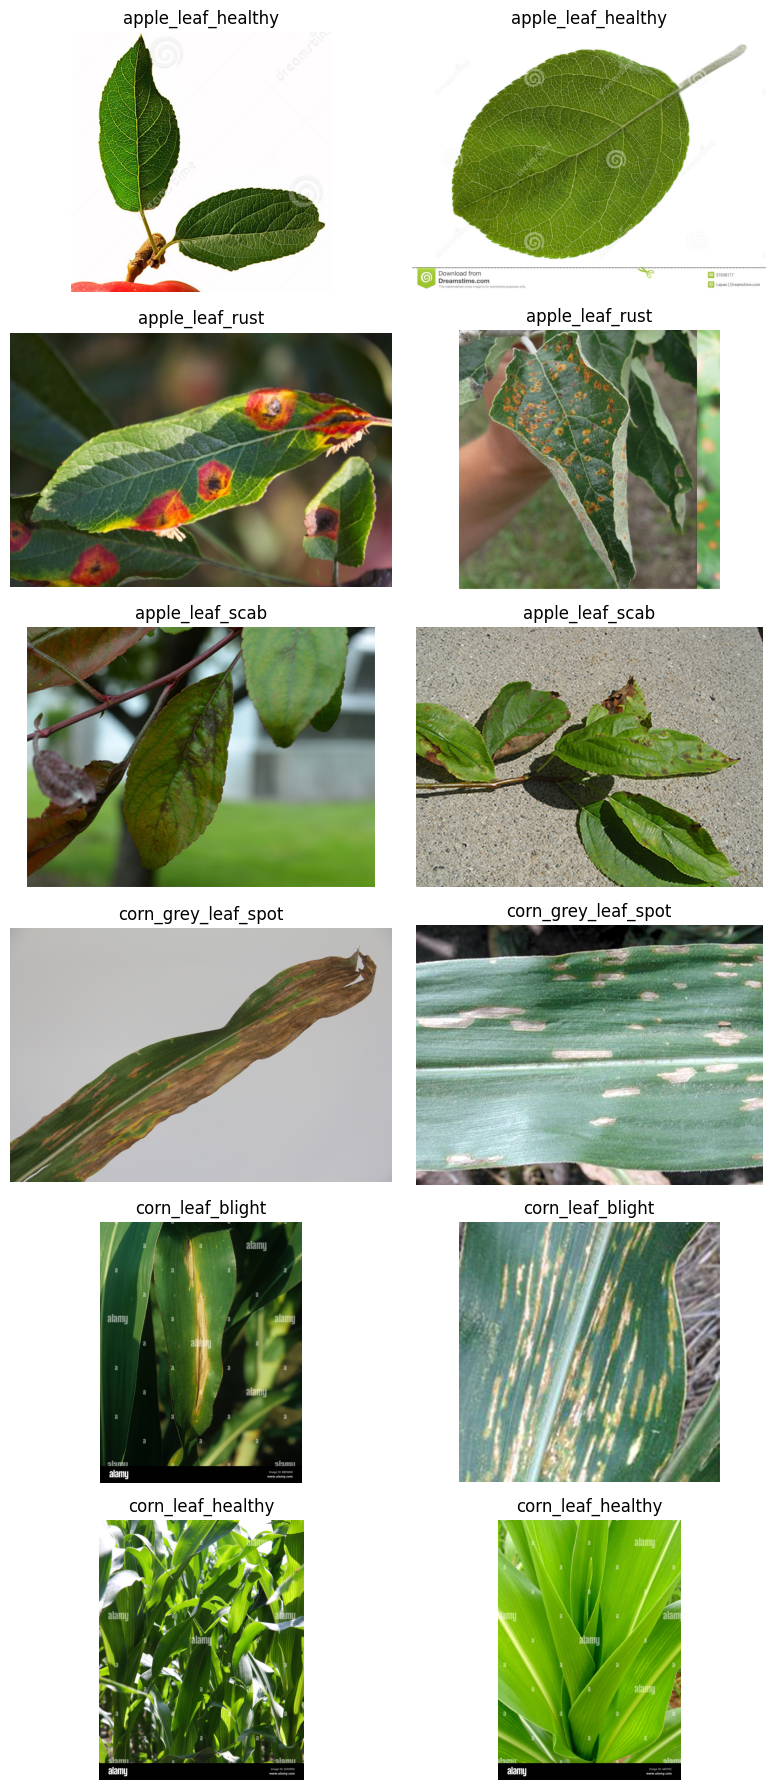

In [11]:
sample_images(COMBINED_DIR, samples_per_class=2, max_classes=6)

## 6. Basic observations template

Use the generated tables and charts to write short observations such as:

- which classes are overrepresented
- which classes are underrepresented
- whether the final split preserves class balance reasonably well
- whether the combined dataset appears more diverse than either individual dataset
